# FRAME: Advanced Usage and Extensions

This notebook builds on [Example.ipynb](https://github.com/ShenHaotv/frame/blob/main/docsrc/Example.ipynb) and demonstrates more advanced usage patterns and extensions of the `frame` method. We assume familiarity with the basic workflow, including data preparation, graph construction, model fitting, and visualization.

Using the North American gray wolf dataset published in Schweizer et al. (2015), we illustrate how to adjust grid and edge configurations, customize model settings, and modify the cross-validation procedure.

## Imports data and setup the `SpatialDiGraph` object

First we import the required packages and set up the `SpatialDiGraph` object:

In [1]:
import numpy as np
import importlib.resources as resources
import os

from sklearn.impute import SimpleImputer
from pandas_plink import read_plink

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from frame.utils import prepare_graph_inputs
from frame.cross_validation import run_cv
from frame import SpatialDiGraph, Vis

os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"
      
data_path = data_path = resources.files("frame").joinpath("data/")
(bim, fam, G) = read_plink("{}/wolf".format(data_path));
imp = SimpleImputer(missing_values=np.nan, strategy="mean")
genotypes = imp.fit_transform((np.array(G)).T)

coord = np.loadtxt("{}/wolf.coord".format(data_path))  
outer = np.loadtxt("{}/wolf.outer".format(data_path))  
grid_path = "{}/grid_440.shp".format(data_path)  

outer, edges, grid, _ = prepare_graph_inputs(coord=coord, 
                                             ggrid=grid_path,
                                             buffer=0,
                                             outer=outer)

sp_digraph = SpatialDiGraph(genotypes, coord, grid, edges)

Mapping files: 100%|██████████| 3/3 [00:00<00:00, 50.89it/s]


## Visualize and adjust the network:

We now visualize the network:

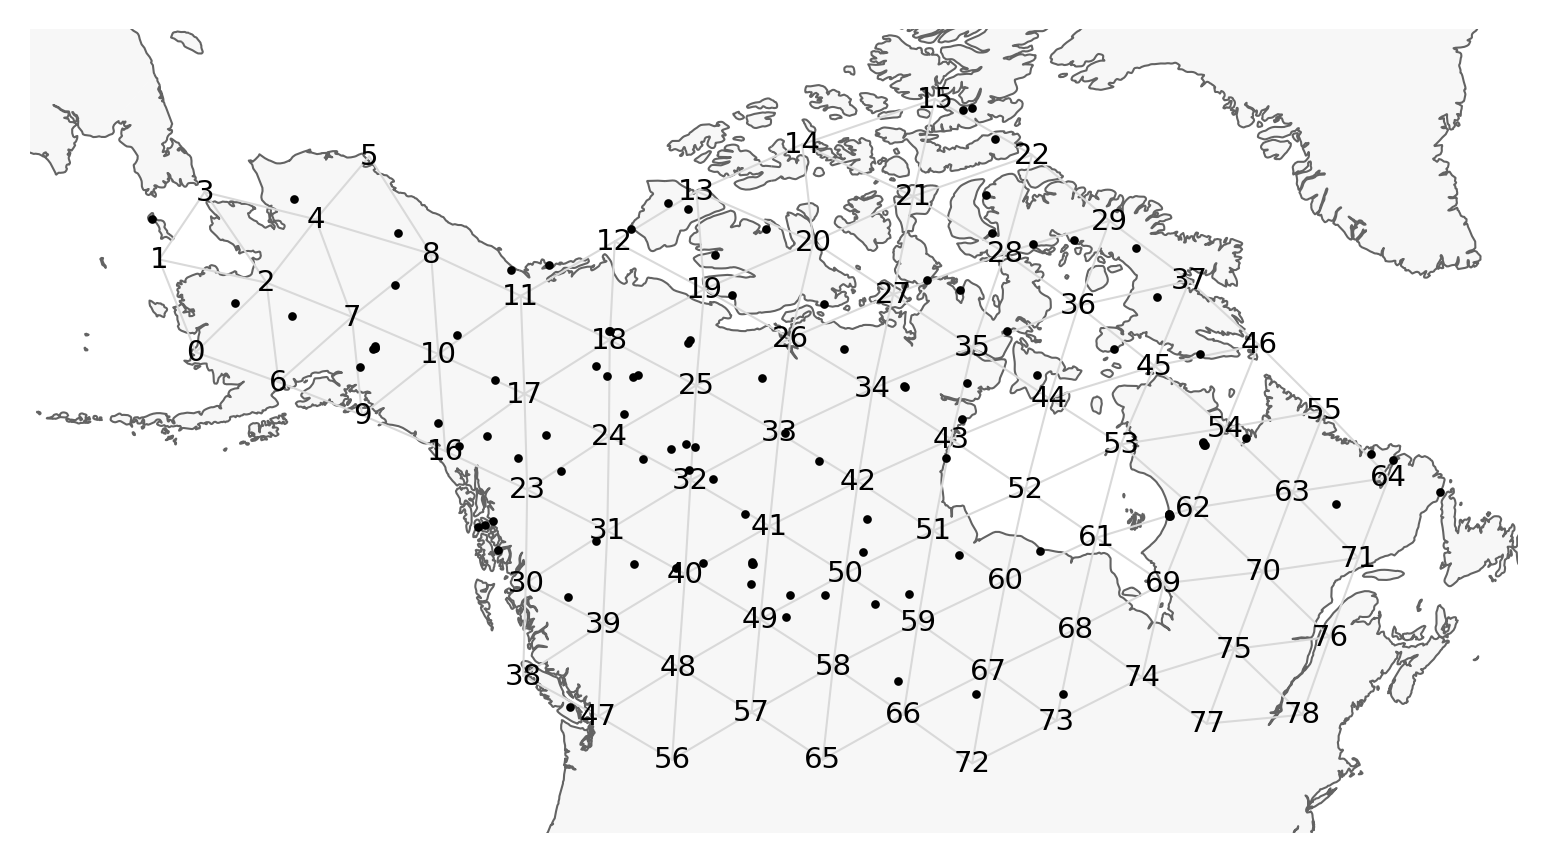

In [2]:
projection = ccrs.EquidistantConic(central_longitude=-108.842926, central_latitude=66.037547)
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Vis(ax, sp_digraph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=200, sample_pt_size=10, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_samples()
v.draw_edges(mode=False)
v.check_nodes_idx()

plt.show()

Assume we would like to fine-tune the grid and edge configuration as follows (node indices are 0-based):

1. Move grid node 1 left-upward
2. Delete node 5,52,77 and 78
3. Add an edge between nodes 16 and 30
4. Delete the edge between nodes 53 and 61

We do this as follows:

In [3]:
# Move grid node 1 left-upward
grid[1,:]=grid[1,:]+[-2.5,1.5]

# Delete node 5,52,77 and 78
grid_delete=[5,52,77,78]
mask = np.ones(len(grid), dtype=bool)
mask[grid_delete] = False
grid_new= grid[mask]

# Add an edge between nodes 16 and 30
additional_edges=np.array([[16,30]])
updated_edges=np.vstack((edges,additional_edges))

# Delete the edge between nodes 53 and 61
edges_to_delete = np.array([[53,61]])
mask_new = np.array([not np.any(np.all(edge == edges_to_delete, axis=1)) for edge in updated_edges])
edges_new=updated_edges[mask_new]

# Creating a mapping of old indexes to new indexes
mapping = {old_idx: new_idx for new_idx, old_idx in enumerate([i for i in range(len(grid)) if i not in grid_delete])}
valid_edges = np.array([edge for edge in edges_new if all(node in mapping for node in edge)])

# Adjusting edges based on new indexes
edges_new = np.vectorize(mapping.get)(valid_edges)

# Construct the new `SpatialDiGraph` object
sp_digraph = SpatialDiGraph(genotypes, coord, grid_new, edges_new)

We now visualize the new network:

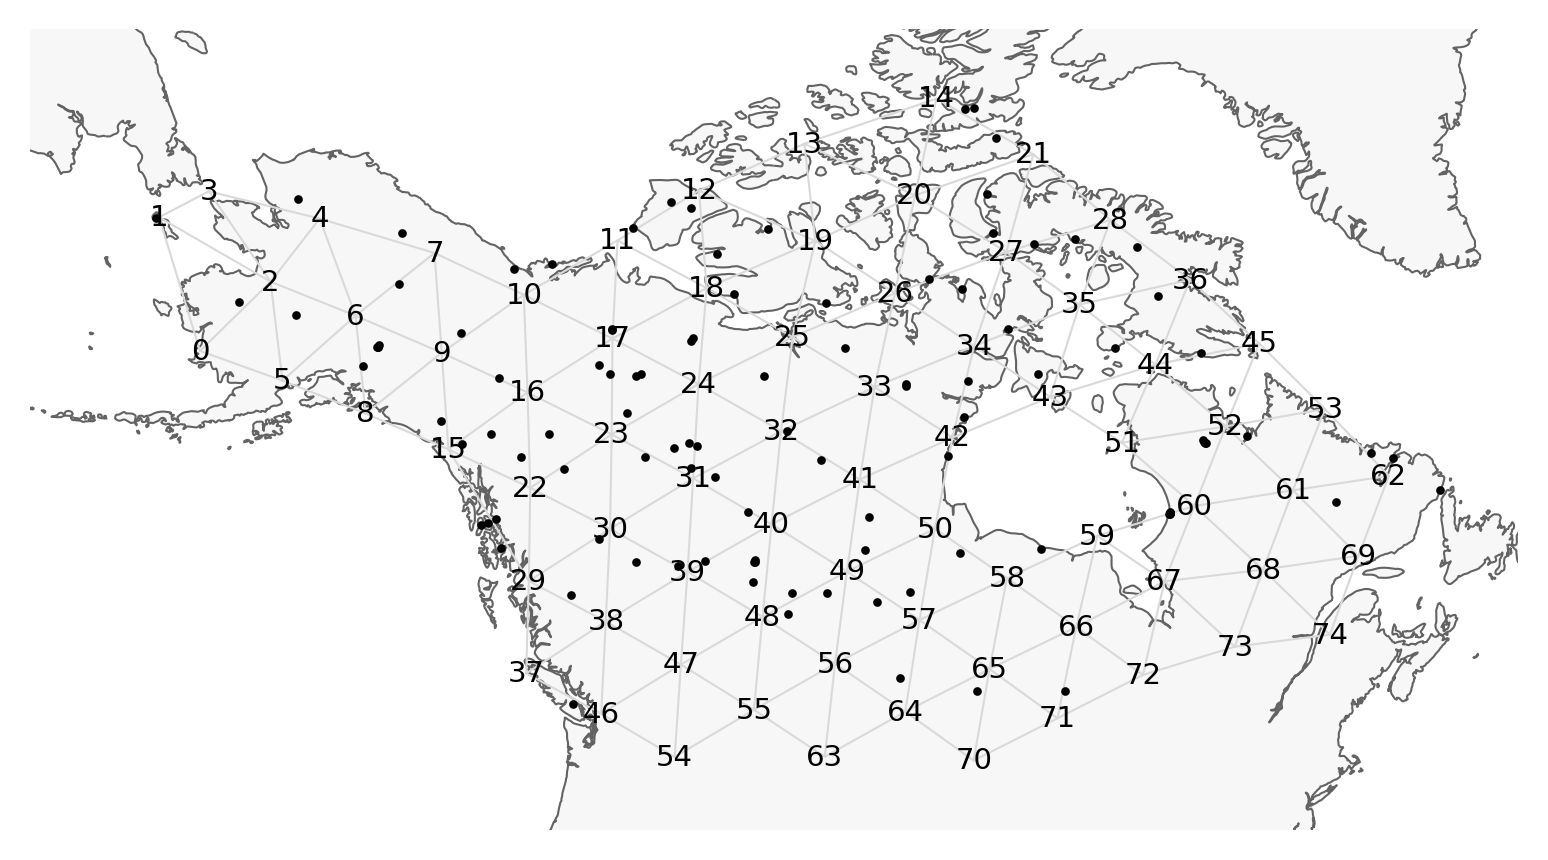

In [4]:
projection = ccrs.EquidistantConic(central_longitude=-108.842926, central_latitude=66.037547)
fig = plt.figure(dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=projection)  
v = Vis(ax, sp_digraph, projection=projection, edge_width=.5, 
        edge_alpha=1, edge_zorder=200, sample_pt_size=10, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10)
v.draw_map()
v.draw_samples()
v.draw_edges(mode=False)
v.check_nodes_idx()

plt.show()

## Customize model setting and cross-validation procedure

Here we explore more advanced model settings and cross-validation procedures. In the default configuration, the parameter $\alpha$ is constrained to the interval $[0,1]$, with its initial value set to the midpoint of the range (i.e., $0.5$). Alternatively, the range of $\alpha$ can be specified manually. In this example, we restrict $\alpha$ to the range $[0.5,1]$, so the default initial value becomes $0.75$. This setting is applied consistently to both the warm-up fitting stage and the cross-validation stage.

Moreover, we adopt a two-stage cross-validation strategy: we first perform a coarse grid search to identify a promising region of the parameter space, followed by a finer grid search to refine the estimate.

In [5]:
lamb_m_warmup = 1e3
lamb_m_grid = np.geomspace(1e-3, 1e3,13)[::-1]

alpha_lb=0.5
alpha_ub=1

cv_errs,node_train_idxs=run_cv(sp_digraph,
                               n_folds=10,
                               alpha_lb_warmup=alpha_lb,
                               alpha_ub_warmup=alpha_ub,
                               alpha_lb=alpha_lb,
                               alpha_ub=alpha_ub,
                               lamb_m_grid=lamb_m_grid,
                               lamb_m_warmup=lamb_m_warmup,
                               factr=1e10,
                               random_state=100)

if np.argmin(cv_errs)==0:
   lamb_m_grid_fine=np.geomspace(lamb_m_grid[0],lamb_m_grid[1],7)[::-1]

elif np.argmin(cv_errs)==12:
     lamb_m_grid_fine=np.geomspace(lamb_m_grid[11],lamb_m_grid[12], 7)[::-1]
     
else:
    lamb_m_grid_fine=np.geomspace(lamb_m_grid[np.argmin(cv_errs)-1],lamb_m_grid[np.argmin(cv_errs)+1], 7)[::-1]

cv_errs_fine,node_train_idxs_fine=run_cv(sp_digraph,
                                         n_folds=10,
                                         alpha_lb_warmup=alpha_lb,
                                         alpha_ub_warmup=alpha_ub,
                                         alpha_lb=alpha_lb,
                                         alpha_ub=alpha_ub,
                                         lamb_m_grid=lamb_m_grid_fine,
                                         lamb_m_warmup=lamb_m_warmup,
                                         factr=1e10,
                                         random_state=100,
                                         outer_verbose=True,
                                         inner_verbose=False,
                                         node_train_idxs=node_train_idxs)

lamb_m_opt=lamb_m_grid_fine[np.argmin(cv_errs_fine)]
lamb_m_opt=float("{:.3g}".format(lamb_m_opt))


 fold= 1
iteration lambda_m=13/13
 fold= 2
iteration lambda_m=13/13
 fold= 3
iteration lambda_m=13/13
 fold= 4
iteration lambda_m=13/13
 fold= 5
iteration lambda_m=13/13
 fold= 6
iteration lambda_m=13/13
 fold= 7
iteration lambda_m=13/13
 fold= 8
iteration lambda_m=13/13
 fold= 9
iteration lambda_m=13/13
 fold= 10
iteration lambda_m=13/13
 fold= 1
iteration lambda_m=7/7
 fold= 2
iteration lambda_m=7/7
 fold= 3
iteration lambda_m=7/7
 fold= 4
iteration lambda_m=7/7
 fold= 5
iteration lambda_m=7/7
 fold= 6
iteration lambda_m=7/7
 fold= 7
iteration lambda_m=7/7
 fold= 8
iteration lambda_m=7/7
 fold= 9
iteration lambda_m=7/7
 fold= 10
iteration lambda_m=7/7

## Fit `FRAME` and visualize results

Next we select the optimal $\lambda_m$ based on the cross-validation results and fit the `FRAME` model using this value. To be consistent with the cross validation step, we use the warm up fitting as the intial value and then fit with stricter converging criteria: 

In [6]:
sp_digraph.fit(lamb_m=lamb_m_warmup, 
               alpha_lb=alpha_lb,
               alpha_ub=alpha_ub,
               factr=1e10)
logm = np.log(sp_digraph.m)
logc = np.log(sp_digraph.c)
trans_alpha=np.log((sp_digraph.alpha-alpha_lb)/(alpha_ub-sp_digraph.alpha))

sp_digraph.fit(lamb_m=lamb_m_opt,
               factr=1e7,
               alpha_lb=alpha_lb,
               alpha_ub=alpha_ub,
               logm_init=logm,
               logc_init=logc,
               trans_alpha_init=trans_alpha)


lambda=1000.0000000, converged in 26 iterations, train_loss=-765795.4209913
lambda=0.1000000, converged in 669 iterations, train_loss=-783199.5319795

Now we can visualize the fitting results and plot the cv error:

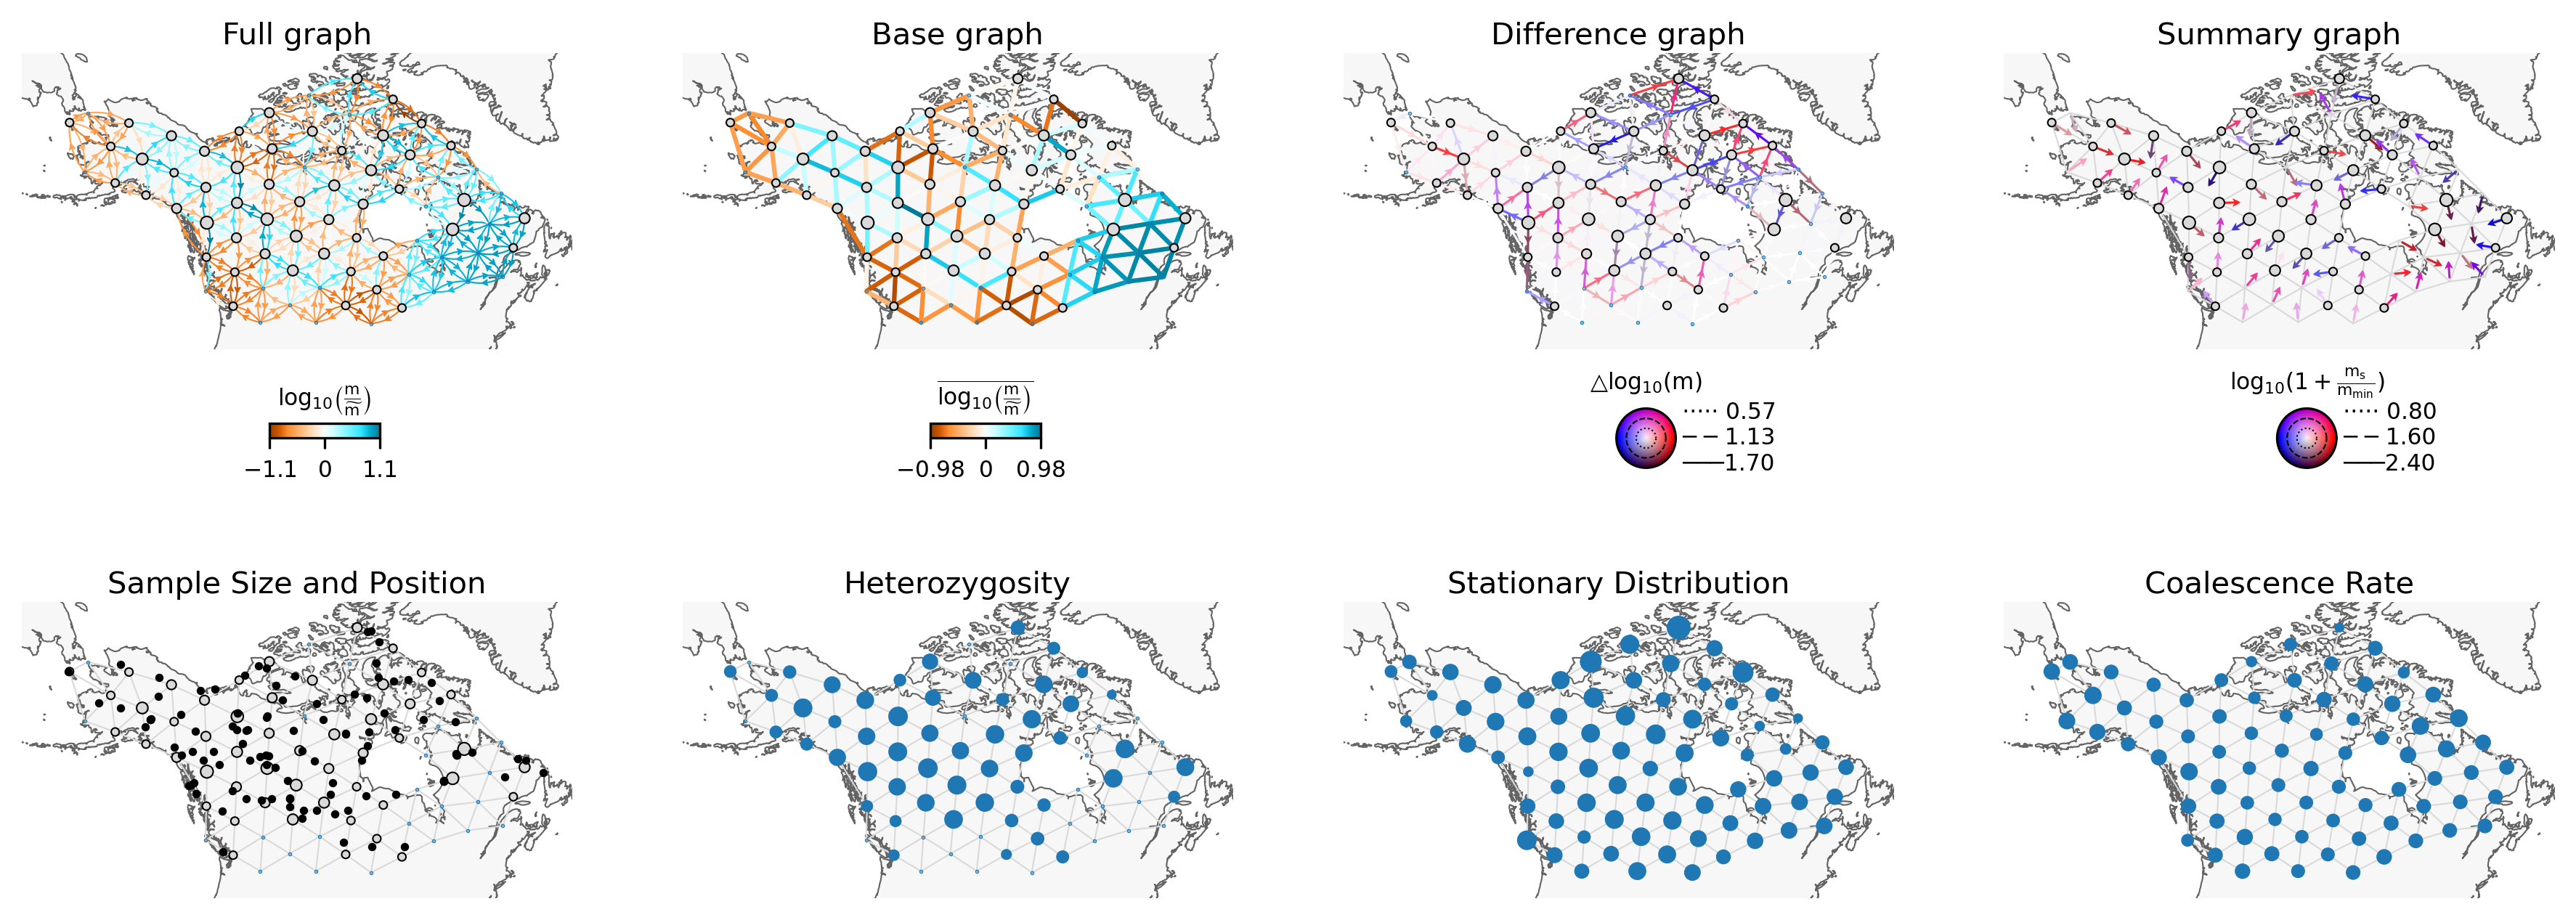

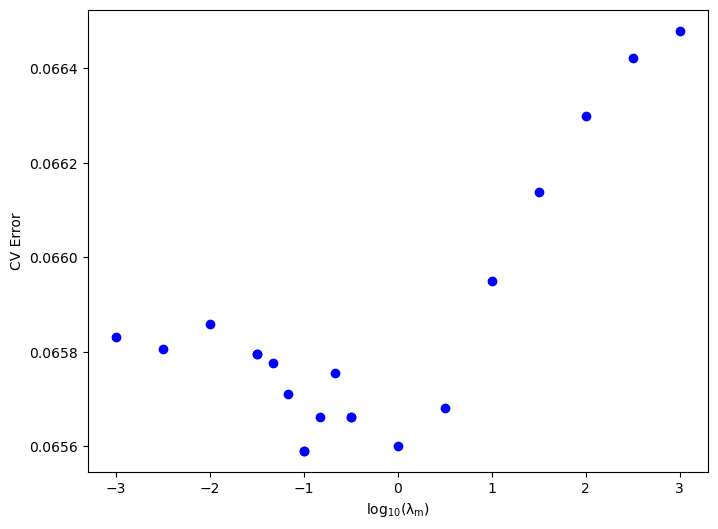

In [7]:
projection = ccrs.EquidistantConic(
    central_longitude=-108.842926, central_latitude=66.037547)

fig, axs= plt.subplots(2, 4, figsize=(15, 6), dpi=300,
                        subplot_kw={'projection': projection})

v = Vis(axs[0,0], sp_digraph, projection=projection, edge_width=0.5,
        edge_alpha=1, edge_zorder=100, sample_pt_size=20,
        obs_node_size=5, sample_pt_color="black",
        cbar_font_size=7.5, cbar_ticklabelsize=7.5, 
        cbar_bbox_to_anchor=(0.45, -0.3, 1, 1),   
        compass_bbox_to_anchor=(0.45, -0.4), compass_radius=0.2, compass_pad=0.2,
        compass_font_size=7.5,mutation_scale=4.5)

v.digraph_wrapper(axs, node_scale=[5, 5, 5])

plt.figure(figsize=(8, 6))
plt.plot(np.log10(lamb_m_grid), cv_errs, 'bo')  
plt.plot(np.log10(lamb_m_grid_fine), cv_errs_fine, 'bo')  
plt.xlabel(r"$\mathrm{log}_{10}(\mathrm{\lambda_m})$")
plt.ylabel('CV Error')

plt.show()